## **Prediksi Kadar NO₂ di Kabupaten Pamekasan Menggunakan KNN Regression**

### **Latar Belakang**

Pencemaran udara merupakan salah satu masalah lingkungan yang dapat memengaruhi kesehatan manusia. Salah satu polutan udara yang banyak ditemukan adalah Nitrogen Dioksida (NO₂) yang berasal dari kendaraan bermotor, pembakaran bahan bakar, dan aktivitas industri. Kadar NO₂ yang tinggi dapat menurunkan kualitas udara serta berdampak pada kesehatan pernapasan.

Kabupaten Pamekasan merupakan salah satu wilayah di Pulau Madura yang memiliki aktivitas transportasi dan pertumbuhan penduduk yang terus berkembang. Oleh karena itu, diperlukan pemantauan kadar NO₂ untuk mengetahui kondisi kualitas udara di wilayah tersebut.

Pada penelitian ini digunakan data satelit Sentinel-5P dari Copernicus Data Space Ecosystem untuk memperoleh data NO₂ harian di Kabupaten Pamekasan. Data tersebut kemudian diolah dan digunakan untuk memprediksi kadar NO₂ menggunakan metode K-Nearest Neighbor (KNN) Regression.

### **1. Pengumpulan Data**

Data yang digunakan pada penelitian ini adalah data kadar Nitrogen Dioksida (NO₂) harian di wilayah Kabupaten Pamekasan. Data diperoleh dari satelit Sentinel-5P melalui platform Copernicus Data Space Ecosystem menggunakan layanan OpenEO.

Langkah pertama adalah membuat akun pada Copernicus Data Space dan melakukan login. Setelah itu dilakukan autentikasi menggunakan library OpenEO agar Python dapat mengakses data satelit.

#### **a. Install Library**

In [1]:
!pip install -q openeo pandas matplotlib scikit-learn openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.5/345.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.5 MB/s eta 0:00:00


**Penjelasan**

Kode ini digunakan untuk menginstal library yang dibutuhkan selama penelitian.

* openeo → Mengambil data satelit Sentinel-5P dari Copernicus.
* pandas → Mengolah data tabular.
* matplotlib → Membuat grafik visualisasi.
* scikit-learn → Membuat model KNN Regression.
* openpyxl → Membaca atau menyimpan file Excel.

#### **b. Import Library dan koneski**

In [2]:
import openeo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

**Penjelasan**

Kode ini digunakan untuk memanggil library yang akan digunakan selama proses pengolahan data dan pemodelan.

In [3]:
connection = openeo.connect(
    "openeo.dataspace.copernicus.eu"
)

connection.authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=MDSB-PIZC 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


<Connection to 'https://openeo.dataspace.copernicus.eu/openeo/1.2/' with OidcBearerAuth>

**Penjelasan**

Kode ini digunakan untuk menghubungkan Google Colab dengan layanan Copernicus Data Space Ecosystem.

Saat dijalankan, pengguna akan diminta login menggunakan akun Copernicus agar dapat mengakses data satelit.

#### **c. Menentukan Area Penelitian (AOI)**

In [4]:
aoi = {
    "type": "Polygon",
    "coordinates": [[
        [113.2959741, -7.2598885],
        [113.4902681, -6.8698443],
        [113.8011241, -6.8786709],
        [113.6867826, -7.2863201],
        [113.2959741, -7.2598885]
    ]]
}

**Penjelasan**

AOI (Area of Interest) merupakan wilayah penelitian yang akan diambil datanya.

Koordinat tersebut diperoleh dari GeoJSON dan membentuk area Kabupaten Pamekasan.

Code diatas memerlukan titik koordinasi area yang akan diambil data
-nya, untuk mengambil titik koordinasi kaian kunjungi webiste https://geojson.io/?map=8.33/-7.1/113.64#map=14.8/-7.04732/112.69463. Didalam website tersebut kalian akan memilih daerah dengan cara memberi shape kotak didaerah yang ingin kalian ambil datanya.

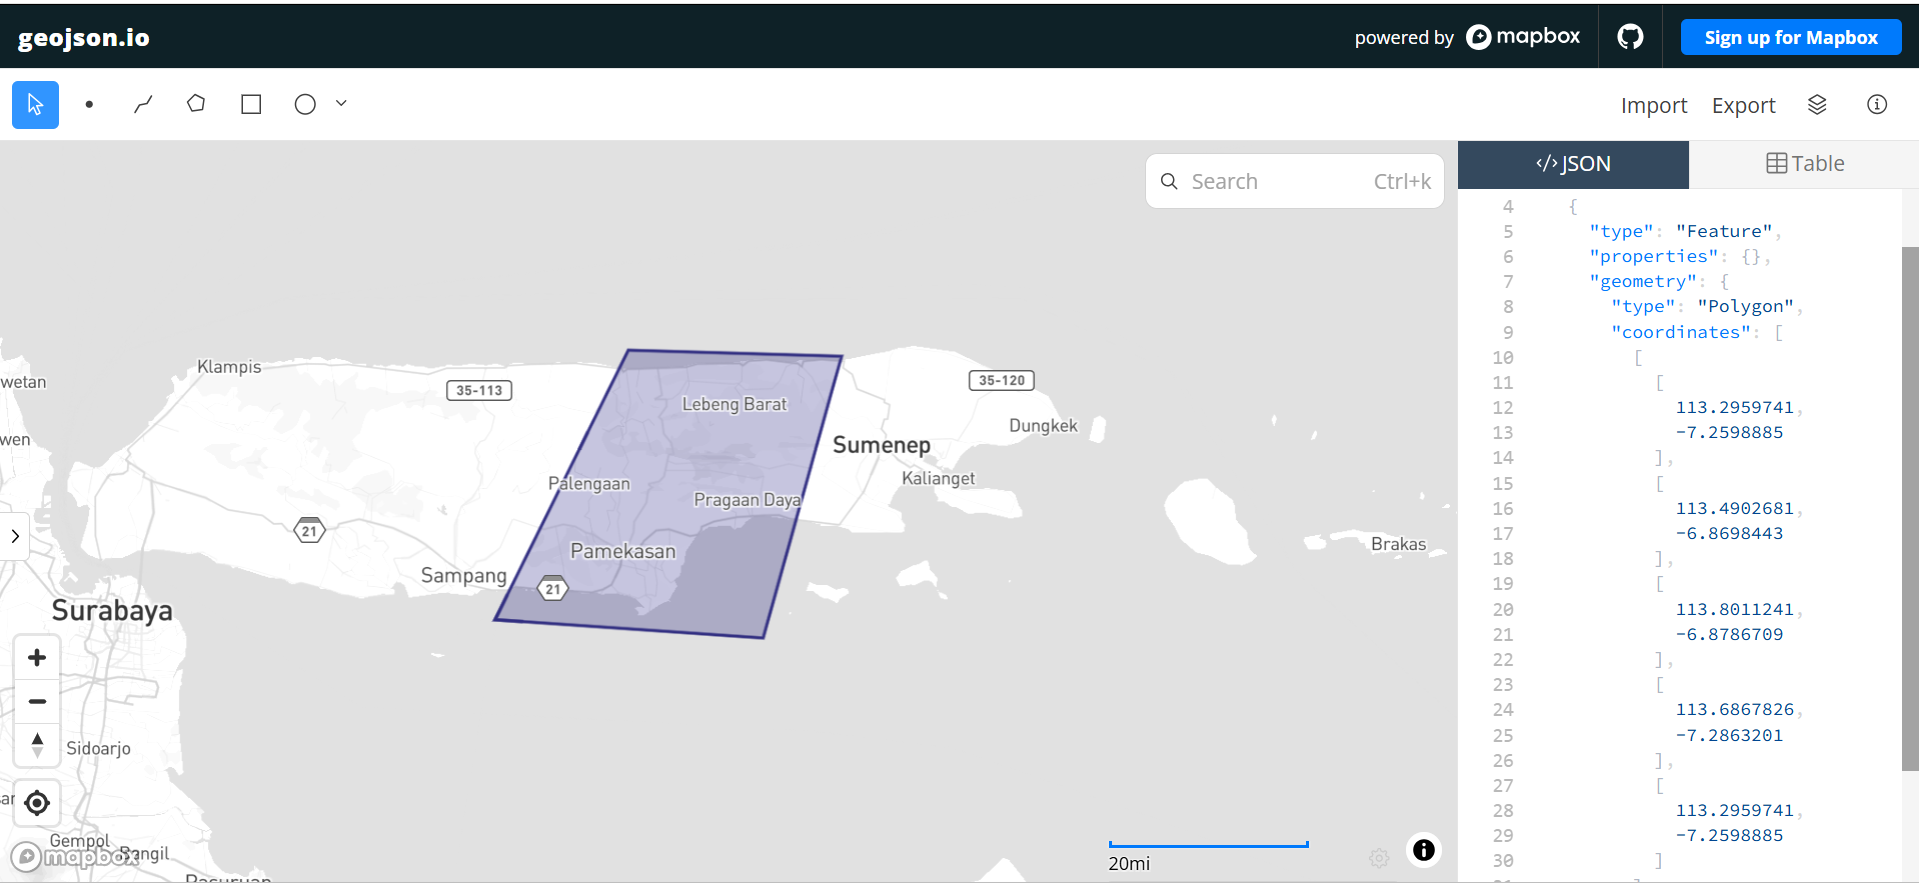

Di panel sebelah kanan terdapat data JSON yang berupa koordinat daerah yang kalian pilih, kalian salin terus sesuaikan dengan code diatas di bagian variabel “aoi” dan spatial_extent.

#### **d. Mengambil Data NO₂**

In [5]:
s5p = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2023-10-01", "2025-10-01"],
    spatial_extent={
        "west":113.2959741,
        "south":-7.2863201,
        "east":113.8011241,
        "north":-6.8698443
    },
    bands=["NO2"]
)

**Penjelasan**

Kode ini digunakan untuk mengambil data NO₂ dari satelit Sentinel-5P.

Parameter yang digunakan:

* **temporal_extent** → rentang waktu pengamatan.
* **spatial_extent**→ batas wilayah penelitian.
* **bands=["NO2"]** → hanya mengambil data Nitrogen Dioksida.

In [6]:
s5p_daily = s5p.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

**Penjelasan**

Dalam satu hari dapat terdapat beberapa pengamatan satelit.

Kode ini digunakan untuk menghitung rata-rata NO₂ harian sehingga setiap hari hanya memiliki satu nilai.

In [7]:
s5p_aoi = s5p_daily.aggregate_spatial(
    geometries=aoi,
    reducer="mean"
)

**Penjelasan**

Kode ini digunakan untuk menghitung rata-rata NO₂ pada seluruh wilayah Pamekasan.

Hasilnya berupa data time series harian.

####**e. Menyimpan Data**

In [9]:
job = s5p_aoi.create_job(
    out_format="CSV",
    title="NO2_Pamekasan"
)

**Penjelasan**

Membuat proses pengambilan data pada server Copernicus.

In [10]:
job.start_and_wait()

0:00:00 Job 'j-260603031259488bae53a499536a1fbe': send 'start'
0:00:39 Job 'j-260603031259488bae53a499536a1fbe': queued (progress 0%)
0:00:44 Job 'j-260603031259488bae53a499536a1fbe': queued (progress 0%)
0:00:51 Job 'j-260603031259488bae53a499536a1fbe': queued (progress 0%)
0:00:59 Job 'j-260603031259488bae53a499536a1fbe': running (progress N/A)
0:01:09 Job 'j-260603031259488bae53a499536a1fbe': running (progress N/A)
0:01:21 Job 'j-260603031259488bae53a499536a1fbe': running (progress N/A)
0:01:37 Job 'j-260603031259488bae53a499536a1fbe': running (progress N/A)
0:01:56 Job 'j-260603031259488bae53a499536a1fbe': running (progress N/A)
0:02:20 Job 'j-260603031259488bae53a499536a1fbe': running (progress N/A)
0:02:50 Job 'j-260603031259488bae53a499536a1fbe': running (progress N/A)
0:03:28 Job 'j-260603031259488bae53a499536a1fbe': running (progress N/A)
0:04:15 Job 'j-260603031259488bae53a499536a1fbe': running (progress N/A)
0:05:13 Job 'j-260603031259488bae53a499536a1fbe': running (progress

<BatchJob job_id='j-260603031259488bae53a499536a1fbe'>

**Penjelasan**

Menjalankan proses pengambilan data dan menunggu hingga selesai.

In [17]:
results = job.get_results()
results.download_files("hasil_no2")

[PosixPath('hasil_no2/timeseries.csv'),
 PosixPath('hasil_no2/job-results.json')]

**Penjelasan**

Mengunduh hasil pengambilan data ke folder lokal Google Colab.

#### **f. Membaca Data CSV**

In [19]:
import os

files = os.listdir("hasil_no2")

print(files)

csv_file = None

for f in files:
    if f.endswith(".csv"):
        csv_file = os.path.join("hasil_no2", f)

print("File CSV:", csv_file)

['timeseries.csv', 'job-results.json']
File CSV: hasil_no2/timeseries.csv


In [20]:
df = pd.read_csv(csv_file)

**Penjelasan**

Membaca file CSV hasil pengambilan data menjadi DataFrame Pandas.

In [21]:
df["date"] = pd.to_datetime(df["date"])

**Penjelasan**

Mengubah kolom tanggal menjadi format datetime agar dapat digunakan untuk analisis time series.

#### **g. Visualisasi Data Harian**

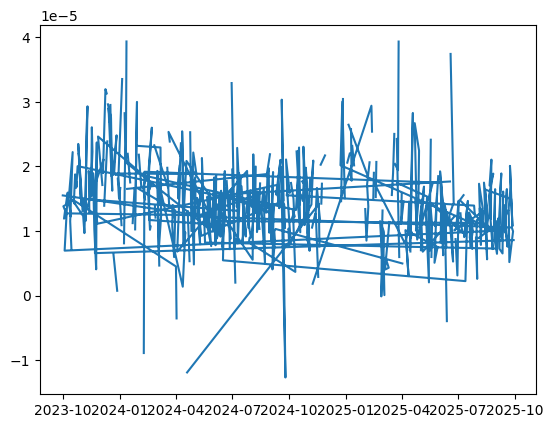

In [22]:
plt.plot(
    df["date"],
    df["NO2"]
)

**Penjelasan**

Menampilkan grafik perubahan kadar NO₂ harian selama periode penelitian.

Tujuannya untuk melihat pola naik-turun kadar NO₂.

### **2. Preprocessing Data**

Pada tahap preprocessing dilakukan pengisian missing value menggunakan interpolasi linear dan deteksi outlier menggunakan metode Interquartile Range (IQR).

#### **h. Mengatasi Missing Value**

In [24]:
full_range = pd.date_range(
    start=df["date"].min(),
    end=df["date"].max(),
    freq="D"
)

**Penjelasan**

Membuat daftar tanggal lengkap dari awal hingga akhir periode penelitian.

In [28]:
df["NO2"] = (
    df["NO2"]
    .interpolate(method="linear")
    .bfill()
    .ffill()
)

**Penjelasan**

Mengisi data yang hilang menggunakan:

* Interpolasi Linear
* Backward Fill
* Forward Fill

Sehingga tidak ada missing value.

#### **i. Deteksi Outlier IQR**

In [29]:
Q1 = df["NO2"].quantile(0.25)
Q3 = df["NO2"].quantile(0.75)

**Penjelasan**

Menghitung kuartil pertama dan kuartil ketiga.

In [30]:
IQR = Q3 - Q1

**Penjelasan**

Menghitung Interquartile Range (IQR).

In [31]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

**Penjelasan**

Menentukan batas bawah dan batas atas data normal.

Data di luar batas tersebut dianggap outlier.

##### **j. Visualisasi Outlier**

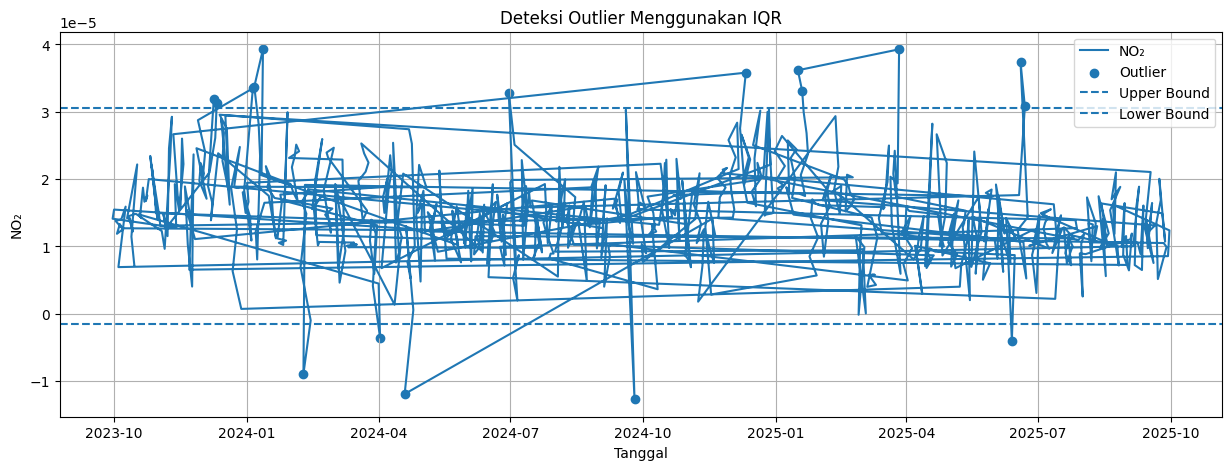

In [35]:
plt.figure(figsize=(15,5))

plt.plot(
    df["date"],
    df["NO2"],
    label="NO₂"
)

plt.scatter(
    outliers["date"],
    outliers["NO2"],
    label="Outlier"
)

plt.axhline(
    upper,
    linestyle="--",
    label="Upper Bound"
)

plt.axhline(
    lower,
    linestyle="--",
    label="Lower Bound"
)

plt.title("Deteksi Outlier Menggunakan IQR")
plt.xlabel("Tanggal")
plt.ylabel("NO₂")

plt.legend()
plt.grid(True)

plt.show()

**Penjelasan**

Menampilkan titik-titik outlier yang terdeteksi oleh metode IQR.

Titik merah menunjukkan nilai yang dianggap tidak normal.

#### **k. Hapus Outlier dan Interpolasi**

In [36]:
df["NO2"] = df["NO2"].mask(
    (df["NO2"] < lower) |
    (df["NO2"] > upper)
)

df["NO2"] = (
    df["NO2"]
    .interpolate()
    .bfill()
    .ffill()
)

**Penjelasan**

Nilai outlier diubah menjadi NaN. dan Mengisi kembali nilai outlier menggunakan interpolasi linear agar data time series tetap kontinu.

#### **l. Visualisasi Setelah Cleaning**

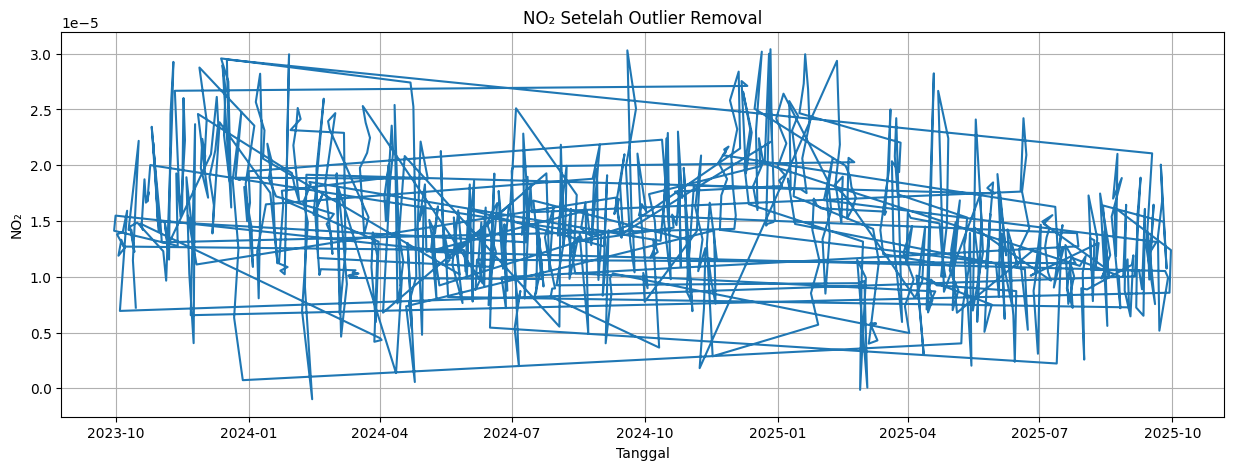

In [37]:
plt.figure(figsize=(15,5))

plt.plot(
    df["date"],
    df["NO2"]
)

plt.title(
    "NO₂ Setelah Outlier Removal"
)

plt.xlabel("Tanggal")
plt.ylabel("NO₂")

plt.grid(True)

plt.show()

### **3. Normalisasi dan KNN Regression**

#### **m. Normalisasi**

In [38]:
scaler = MinMaxScaler()

df["NO2_scaled"] = scaler.fit_transform(
    df[["NO2"]]
)

**Penjelasan**

Normalisasi mengubah nilai NO₂ ke rentang 0–1.

Normalisasi diperlukan karena KNN menggunakan perhitungan jarak antar data.

#### **n. Fungsi KNN**

In [39]:
def create_supervised(data,n_lag):

    temp = pd.DataFrame()

    for i in range(n_lag,0,-1):
        temp[f"lag_{i}"] = data.shift(i)

    temp["target"] = data

    return temp.dropna()


def train_knn(data,lag):

    supervised = create_supervised(data,lag)

    X = supervised.drop(columns=["target"])
    y = supervised["target"]

    X_train,X_test,y_train,y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        shuffle=False
    )

    model = KNeighborsRegressor(
        n_neighbors=5
    )

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    rmse = np.sqrt(
        mean_squared_error(y_test,pred)
    )

    r2 = r2_score(y_test,pred)

    print(f"\nLag {lag}")
    print("RMSE =",rmse)
    print("R2   =",r2)

    return y_test,pred

#### **o. Training Model**

In [40]:
y4,p4 = train_knn(df["NO2_scaled"],4)
y10,p10 = train_knn(df["NO2_scaled"],10)
y30,p30 = train_knn(df["NO2_scaled"],30)


Lag 4
RMSE = 0.17269428801710623
R2   = -0.013339591328536793

Lag 10
RMSE = 0.1681142206985308
R2   = 0.046197111692547366

Lag 30
RMSE = 0.19965794955809602
R2   = -0.3256544837086621


**Penjelasan**

* Membuat model KNN Regression dengan jumlah tetangga terdekat sebanyak 5.
* Melatih model menggunakan data training.
* Menghasilkan prediksi kadar NO₂ pada data testing.

#### **p. Plot Lag 4**

Plotting untuk visualisasi grafik antara label dan prediksi dari kedua data diatas.

4 hari sebelum:

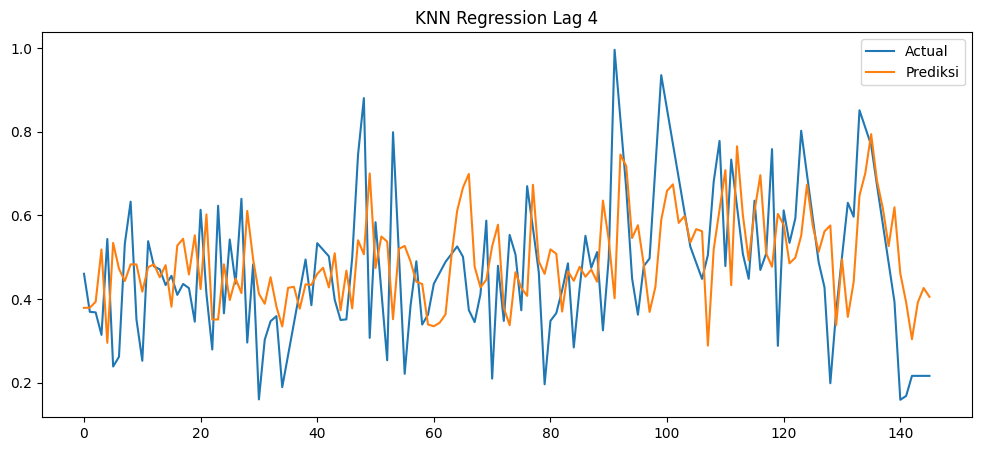

In [41]:
plt.figure(figsize=(12,5))

plt.plot(y4.values,label="Actual")
plt.plot(p4,label="Prediksi")

plt.title("KNN Regression Lag 4")

plt.legend()
plt.show()

10 hari sebelum:

#### **q. Plot Lag 10**

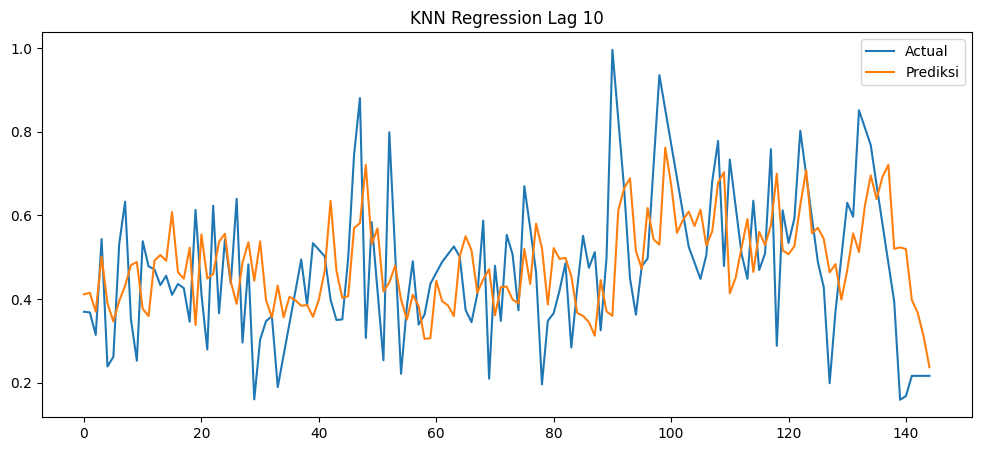

In [42]:
plt.figure(figsize=(12,5))

plt.plot(y10.values,label="Actual")
plt.plot(p10,label="Prediksi")

plt.title("KNN Regression Lag 10")

plt.legend()
plt.show()

#### **r. Plot Lag 30**

30 hari sebelum:

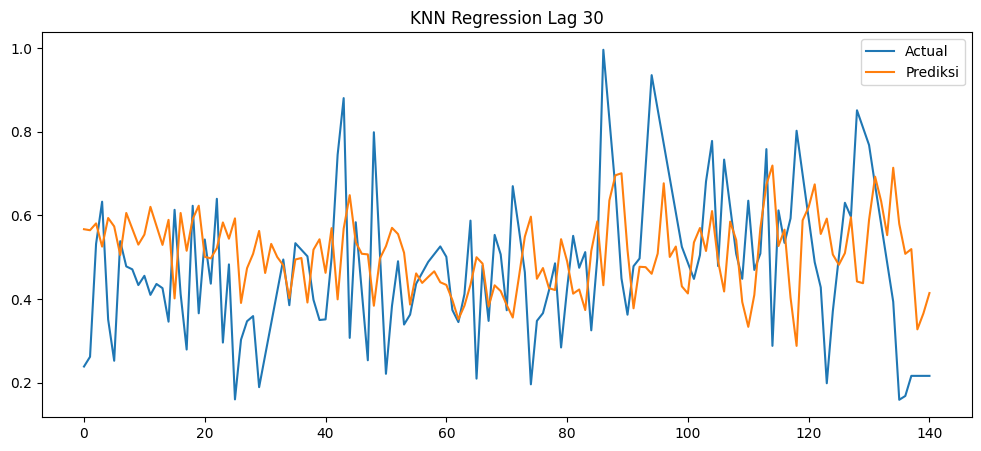

In [43]:
plt.figure(figsize=(12,5))

plt.plot(y30.values,label="Actual")
plt.plot(p30,label="Prediksi")

plt.title("KNN Regression Lag 30")

plt.legend()
plt.show()

**Kesimpulan**

Berdasarkan hasil penelitian, data NO₂ harian Kabupaten Pamekasan berhasil diperoleh dari satelit Sentinel-5P melalui Copernicus Data Space Ecosystem. Data kemudian melalui proses preprocessing berupa penanganan missing value dan outlier menggunakan metode interpolasi linear dan IQR. Selanjutnya dilakukan normalisasi data dan pemodelan menggunakan KNN Regression dengan beberapa variasi lag, yaitu 4 hari, 10 hari, dan 30 hari sebelumnya. Performa model dievaluasi menggunakan RMSE dan R² untuk menentukan model yang memberikan hasil prediksi terbaik terhadap kadar NO₂ di Kabupaten Pamekasan.